## Comparing the preprocessed CFLIB fluxes :

In [1]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline

In [2]:
cflib_data = np.load("cflib_data.npz", allow_pickle = True)     # loading the CFLIB from npz sharma at el (2020)

In [3]:
cflib_data

NpzFile 'cflib_data.npz' with keys: flux, wave, teff, logg, feh...

In [4]:
cflib_data["flux"]          # loading preprocessed CFLIB flux from sharma et al (2020)

array([[1.176708573333929, 1.1760512221903987, 1.173074399498486, ...,
        0.4122635493170717, 0.41270305790417994, 0.41297965237073375],
       [0.040143816502474255, 0.03955856424195762, 0.04061330881936796,
        ..., 1.5610761752147815, 1.5627929888600045, 1.540046457921836],
       [0.22926749402309268, 0.2314625184640081, 0.23468264525356838,
        ..., 0.8415991414094556, 0.838740358780529, 0.8269542794439935],
       ...,
       [0.6101351547497081, 0.6073226639791796, 0.6103089534498088, ...,
        9.85354519046036e-05, 9.85354519046036e-05, 9.85354519046036e-05],
       [0.44463511811891404, 0.4444143500137974, 0.44083050760027165,
        ..., 9.190256391646997e-05, 9.190256391646997e-05,
        9.190256391646997e-05],
       [0.5969016523678589, 0.5911757758409714, 0.5920322877247359, ...,
        0.6558381072735252, 0.6582127407132922, 0.6568357492659957]],
      shape=(850, 4367), dtype=object)

In [5]:
for i in cflib_data:
    print(i)

flux
wave
teff
logg
feh
fname


In [ ]:
for i in range (len(cflib_data["fname"])):          # finding the index of the 5750 star
    if cflib_data["fname"][i] == "5750.fits":
        print(i) 

427


In [7]:
flux_5750 = cflib_data["flux"][613]

In [8]:
len(flux_5750)

4367

In [9]:
final_wave = 3536. + np.arange(4306) * 0.9
original_wave = 3500. + np.arange(4367) * 0.9

Defining the lowest and highest index for the wavelength grid to trim the flux values from 4367 to 4306 :

In [10]:
low_idx = np.argmin(abs(original_wave - final_wave[0]))
high_idx = np.argmin(abs(original_wave - final_wave[-1]))

In [11]:
flux_5750 = flux_5750[low_idx : high_idx + 1]

In [12]:
flux_5750

array([0.7615995617910829, 0.7616713980510469, 0.7730274835996412, ...,
       0.5810681654166192, 0.5734922674325685, 0.5725039333533769],
      shape=(4306,), dtype=object)

In [13]:
len(flux_5750)

4306

#### Comparing the preprocessed CFLIB datas for HD 5750

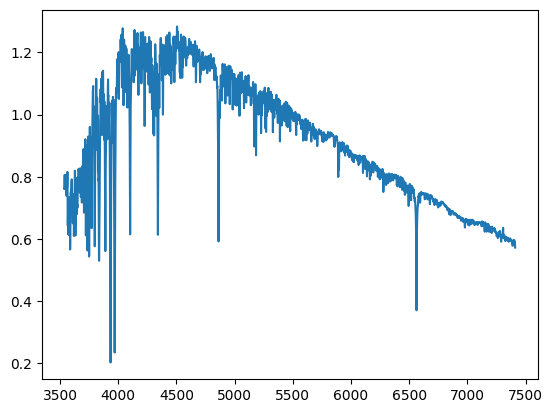

In [14]:
plt.plot(final_wave, flux_5750)

#### Preprocessed flux from preprocessing.py : 

In [15]:
import preprocessing

wavelength, flux = preprocessing.preprocess("../../FITS_data/5750.fits")        # preprocess using the preprocessing.py function - preprocess

In [16]:
flux

array([0.7655043 , 0.77252335, 0.77887404, ..., 0.58216123, 0.58056181,
       0.58010708], shape=(4306,))

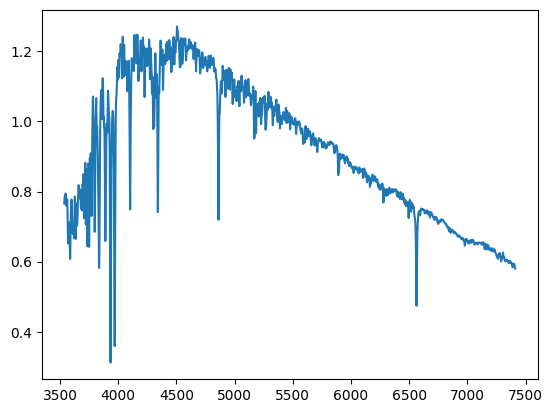

In [17]:
plt.plot(final_wave, flux)

#### Comparing the preprocessed fluxes for the star HD10307 : 

In [18]:
for i in range(len(cflib_data["fname"])):               # finding the index for the 10307 stars
    if cflib_data["fname"][i] == "10307.fits":
        print(i)

6


In [19]:
len(cflib_data["fname"])

850

In [20]:
flux_10307 = cflib_data["flux"][6]
flux_10307 = flux_10307[low_idx : high_idx + 1]     # sharma et al cflib trimmed value
flux_10307

array([0.5443208761555345, 0.5325037116344467, 0.5413711337319257, ...,
       0.6639188821047557, 0.655289531341929, 0.6528475122812818],
      shape=(4306,), dtype=object)

Using preprocessing.py cflib :

In [21]:
wavelength, flux_10307_vyom = preprocessing.preprocess("../../FITS_data/10307.fits")        
flux_10307_vyom

array([0.54912308, 0.55533391, 0.56168774, ..., 0.67746373, 0.67274759,
       0.67117136], shape=(4306,))

Comparing

Text(0.5, 1.0, 'HD10307')

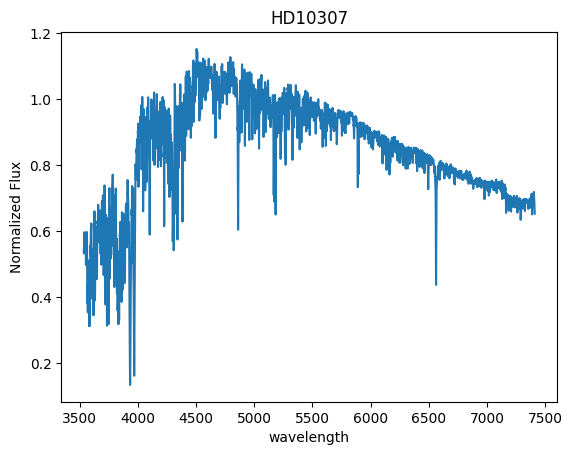

In [22]:
plt.plot(final_wave, flux_10307)        # plotting the sharma et al (2020) preprocessed CFLIB
plt.xlabel("wavelength")
plt.ylabel("Normalized Flux")
plt.title("HD10307")

Text(0.5, 1.0, 'HD10307')

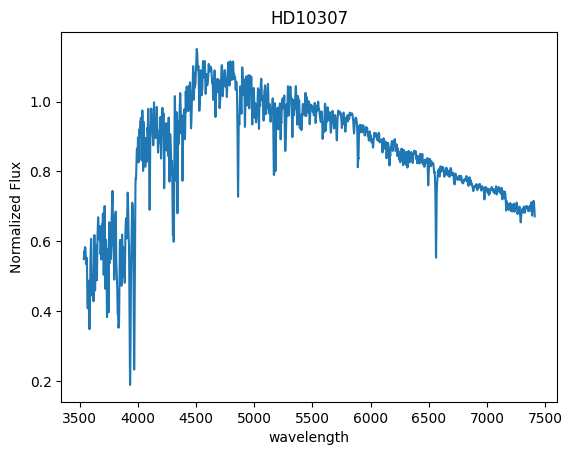

In [23]:
plt.plot(final_wave, flux_10307_vyom)       # plotting the preprocessing.py
plt.xlabel("wavelength")
plt.ylabel("Normalized Flux")
plt.title("HD10307")

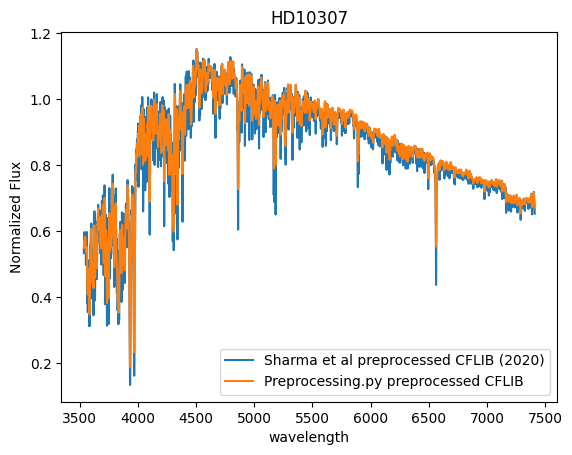

In [24]:
plt.plot(final_wave, flux_10307, label = "Sharma et al preprocessed CFLIB (2020)")
plt.plot(final_wave, flux_10307_vyom, label = "Preprocessing.py preprocessed CFLIB")
plt.xlabel("wavelength")
plt.ylabel("Normalized Flux")
plt.title("HD10307")
plt.legend()